#  Phân loại Hồ sơ Cho vay ngân hàng (Logistic Regression)

Dự án này ứng dụng thuật toán **Logistic Regression (Hồi quy Logistic)** xây dựng từ đầu (from scratch) bằng NumPy để dự đoán khả năng duyệt hồ sơ vay vốn dựa trên hai yếu tố: **Mức lương** và **Thời gian công tác (Kinh nghiệm)**.

---
# 1Cell 1: Khai báo thư viện và Truy xuất dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('data2.csv')

# 2. Tạo ma trận đầu vào X (Gồm Lương và Kinh nghiệm)
# Chuyển vị (.T) để đưa về dạng (d, N) như code mẫu của bạn
X_raw = df[['Luong', 'Kinh_Nghiem']].values.T 
y = df['Cho_Vay'].values

# 3. Thêm hàng số 1 (bias) vào đầu ma trận X
X = np.concatenate((np.ones((1, X_raw.shape[1])), X_raw), axis = 0)

print(f"Kích thước X: {X.shape}") # (3, 40)
print("5 dòng dữ liệu đầu tiên:")
print(df.head())

Kích thước X: (3, 40)
5 dòng dữ liệu đầu tiên:
   Luong  Kinh_Nghiem  Cho_Vay
0     10          1.0        1
1      9          0.5        1
2      5          2.0        1
3      8          2.5        1
4      7          1.5        1


 1. Giải thích về Mô hình Logistic Regression
Mặc dù có tên là "Regression" (Hồi quy), đây thực chất là một thuật toán **Phân loại (Classification)** dùng để dự đoán xác suất của một sự kiện (0 hoặc 1).

### A. Hàm Sigmoid
Để chuyển đổi kết quả tuyến tính thành xác suất (nằm trong khoảng từ 0 đến 1), mô hình sử dụng hàm Sigmoid:
$$\sigma(s) = \frac{1}{1 + e^{-s}}$$



### B. Hàm Tuyến tính Đa biến
Với 2 biến đầu vào là Lương ($x_1$) và Kinh nghiệm ($x_2$), mô hình đi tìm hàm số:
$$s = w_0 + w_1x_1 + w_2x_2$$

* $w_0$: Hệ số chặn (Bias).
* $w_1, w_2$: Trọng số (Weights) thể hiện mức độ ảnh hưởng của từng đặc trưng.

### C. Đường Ranh giới Quyết định (Decision Boundary)
Đường ranh giới phân chia giữa lớp "Cho vay" và "Từ chối" nằm tại vị trí xác suất phân vân nhất ($\sigma(s) = 0.5$, tương đương $s = 0$):
$$w_0 + w_1x_1 + w_2x_2 = 0$$

---

In [2]:
def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]    
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    
    np.random.seed(2) # Đảm bảo kết quả huấn luyện ổn định
    while count < max_count:
        # Xáo trộn dữ liệu (Stochastic Gradient Descent)
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            if count % check_w_after == 0:                
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w

# Bắt đầu huấn luyện mô hình
eta = .05 
d = X.shape[0]
w_init = np.random.randn(d, 1)
w = logistic_sigmoid_regression(X, y, w_init, eta)
w_final = w[-1]

print("Vector trọng số tối ưu w tìm được:")
print(w_final)

Vector trọng số tối ưu w tìm được:
[[-9.02823694]
 [ 0.59216234]
 [ 6.45981982]]


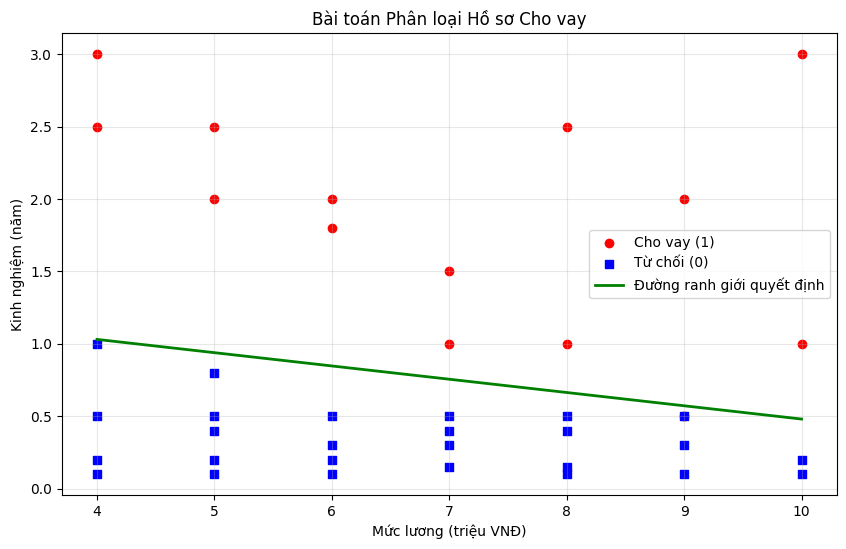

In [3]:
# Tách dữ liệu Cho vay (1) và Từ chối (0) để vẽ màu khác nhau
X_1 = df[df['Cho_Vay'] == 1]
X_0 = df[df['Cho_Vay'] == 0]

plt.figure(figsize=(10, 6))
plt.scatter(X_1['Luong'], X_1['Kinh_Nghiem'], color='red', marker='o', label='Cho vay (1)')
plt.scatter(X_0['Luong'], X_0['Kinh_Nghiem'], color='blue', marker='s', label='Từ chối (0)')

# Công thức đường phân chia: w0 + w1*Luong + w2*KinhNghiem = 0
# => KinhNghiem = -(w0 + w1*Luong) / w2

w0, w1, w2 = w_final.flatten()
x_boundary = np.array([df['Luong'].min(), df['Luong'].max()])
y_boundary = -(w0 + w1 * x_boundary) / w2

plt.plot(x_boundary, y_boundary, 'g-', linewidth=2, label='Đường ranh giới quyết định')

plt.xlabel('Mức lương (triệu VNĐ)')
plt.ylabel('Kinh nghiệm (năm)')
plt.title('Bài toán Phân loại Hồ sơ Cho vay')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
def predict_loan(luong, kinh_nghiem):
    # Tạo vector input [1, Luong, KinhNghiem]
    x_new = np.array([[1], [luong], [kinh_nghiem]])
    prob = sigmoid(np.dot(w_final.T, x_new))[0][0]
    
    result = "ĐƯỢC DUYỆT" if prob >= 0.8 else "TỪ CHỐI (Xác suất thấp)"
    
    print(f"--- KẾT QUẢ DỰ ĐOÁN ---")
    print(f"Lương: {luong}tr, Kinh nghiệm: {kinh_nghiem} năm")
    print(f"Xác suất được vay: {prob*100:.2f}%")
    print(f"Quyết định: {result}")

# Thử nghiệm với hồ sơ: Lương 6 triệu, 1 năm kinh nghiệm
predict_loan(6, 1)

--- KẾT QUẢ DỰ ĐOÁN ---
Lương: 6tr, Kinh nghiệm: 1 năm
Xác suất được vay: 72.80%
Quyết định: TỪ CHỐI (Xác suất thấp)
